<a href="https://colab.research.google.com/github/tensorbytes0202/Deep-learning/blob/main/mobile_net(imagenet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/Untitled folder/archive (4).zip"  # apna filename check kar lena
extract_path = "/content/tiny-imagenet"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done ✅")

Extraction Done ✅


In [3]:
# =====================
# 1. IMPORTS
# =====================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import time
import matplotlib.pyplot as plt

In [4]:
# =====================
# 2. DATA
# =====================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),   # 🔥 added
    transforms.RandomRotation(10),       # 🔥 added
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [5]:

train_data = datasets.ImageFolder(
    "/content/tiny-imagenet/tiny-imagenet-200/train",
    transform=transform
)

val_data = datasets.ImageFolder(
    "/content/tiny-imagenet/tiny-imagenet-200/val",
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [6]:
# =====================
# 3. MODEL
# =====================
model = models.mobilenet_v2(pretrained=True)

# 🔥 allow full training (better results)
for param in model.parameters():
    param.requires_grad = True

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features, 200
)

model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 202MB/s]


In [7]:
# =====================
# 4. TRAIN
# =====================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

train_losses = []
val_accuracies = []

start = time.time()

for epoch in range(7):

    # TRAIN
    total_loss = 0
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # VALIDATION
    model.eval()
    correct, total = 0,0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, pred = torch.max(outputs,1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    acc = 100 * correct / total
    val_accuracies.append(acc)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Val Acc: {acc:.2f}%")

print("Training Time:", time.time()-start)

Epoch 1, Loss: 2.2675, Val Acc: 0.50%
Epoch 2, Loss: 1.3201, Val Acc: 0.48%
Epoch 3, Loss: 1.0983, Val Acc: 0.46%
Epoch 4, Loss: 0.9583, Val Acc: 0.52%
Epoch 5, Loss: 0.8540, Val Acc: 0.54%
Epoch 6, Loss: 0.7701, Val Acc: 0.57%
Epoch 7, Loss: 0.6924, Val Acc: 0.49%
Training Time: 4263.8299441337585


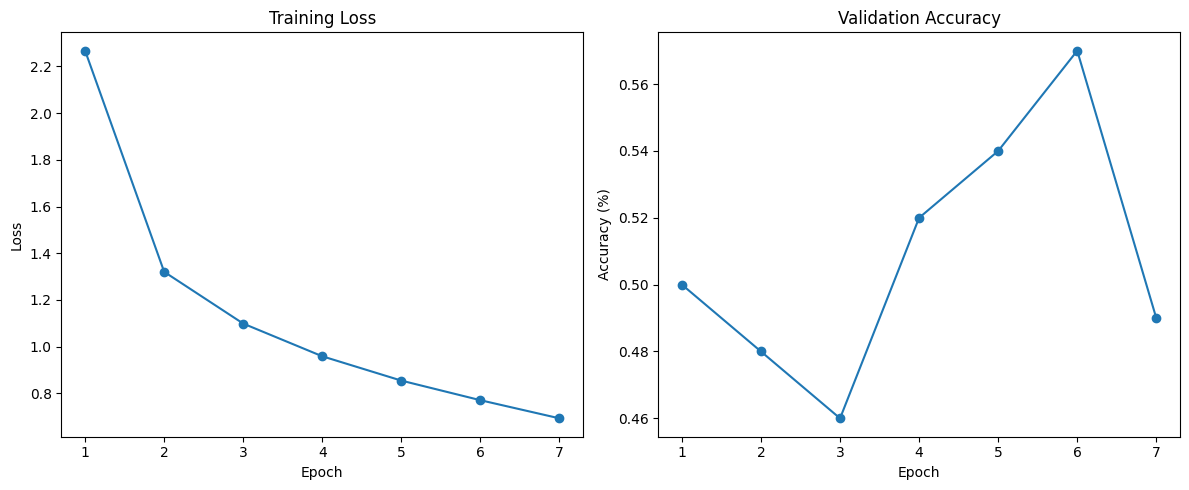

In [10]:
# =====================
# 5. GRAPHS 🔥
# =====================
epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, val_accuracies, marker='o')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()


In [13]:
import os

os.makedirs("outputs/mobilenet", exist_ok=True)

torch.save(model.state_dict(), "outputs/mobilenet/mobilenet_model.pth")

print("MobileNet model saved ✅")

MobileNet model saved ✅
